# Introduction to regression with Neural Networks in TensorFlow
there are many definition for regression problem but in our case predicting a numerical variable based on some other combination of variables even shorter predicting a number

In [1]:
import tensorflow as tf
print(tf.__version__)
print((tf.config.list_physical_devices()))

2.19.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

# Re-import tensorflow to ensure the backend is set (if already imported before setting env var)
import tensorflow as tf

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
Y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

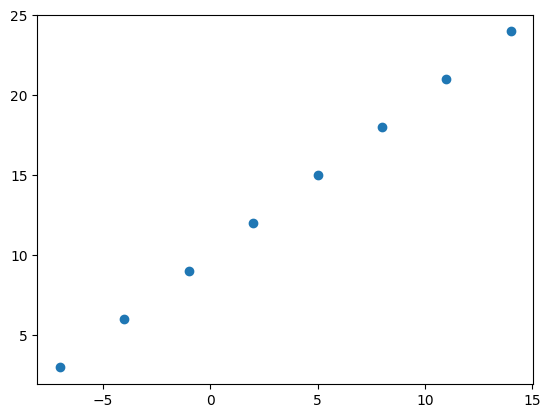

In [4]:
plt.scatter(X, Y)

In [5]:
Y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

# Input and output shape

In [6]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([938000])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([938000], dtype=int32)>)

In [7]:
input_shape = X[0].shape
output_shape = Y[0].shape
input_shape, output_shape

((), ())

In [8]:
X[0].ndim

0

In [9]:
X[0], Y[0]

(np.float64(-7.0), np.float64(3.0))

In [10]:
X = tf.constant(X)
Y = tf.constant(Y)
X, Y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [11]:
X[0].shape, Y[0].shape

(TensorShape([]), TensorShape([]))

## Steps in modelling with TensorFlow

1. Creating a model - define the input an output layer, as well as the hidden layers of a deep learning model.
2. Compiling a model - define the loss and the optimizer and evaluation metrics
3. fitting a model - letting the model try to find pattern sbetween X & y

In [12]:
import keras # Import Keras directly

# set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = keras.Sequential([
    keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss = keras.losses.MeanAbsoluteError(),
              optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
              metrics = [keras.metrics.MeanAbsoluteError()])
# 3. Fit the model
model.fit(tf.expand_dims(X, axis = -1), Y, epochs = 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 18.4372 - mean_absolute_error: 18.4372
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 18.4312 - mean_absolute_error: 18.4312
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 18.4252 - mean_absolute_error: 18.4252
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 18.4192 - mean_absolute_error: 18.4192
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 18.4132 - mean_absolute_error: 18.4132


In [13]:
tf.expand_dims(X, axis = -1), X

(<tf.Tensor: shape=(8, 1), dtype=float64, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>)

In [14]:
model.predict(tf.cast([17], dtype=tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


array([[-18.325813]], dtype=float32)

## Improving our model
we can improve our model, by altering the steps we took to create a model.

1. creating a model - here we migh add more layers, increase the number of hidden units( all called neurons) within each of the hidden layers, change the activation function of each layer.
2. Compiling a model - here we might change the optimization function or perhaps the learning rate of the optimization fucntion
3. Fitting a model - here we might fir a model for more epochs or more data

In [15]:
# rebuild
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = [tf.keras.metrics.MAE])
model.fit(tf.expand_dims(X, axis = -1), Y, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13.3781 - mean_absolute_error: 13.3781
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 13.2456 - mean_absolute_error: 13.2456
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 13.1131 - mean_absolute_error: 13.1131
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 12.9806 - mean_absolute_error: 12.9806
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 12.8481 - mean_absolute_error: 12.8481
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.7156 - mean_absolute_error: 12.7156
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 12.5831 - mean_absolute_error: 12.5831
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.4506 - mean_absolute_error: 12.4506
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 12.3181 - mean_absolute_error: 12.3181
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 12.1856 - mean_absolute_error: 12.1856
Epoch 11/100
1/1 ━━━━━━━━━━━━

In [16]:
model.predict(tf.cast([17], dtype = tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


array([[30.022251]], dtype=float32)

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
              metrics = [tf.keras.metrics.MAE])
model.fit(tf.expand_dims(X, axis = -1), Y, epochs = 200)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 14.7612 - mean_absolute_error: 14.7612
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 14.3112 - mean_absolute_error: 14.3112
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 13.8612 - mean_absolute_error: 13.8612
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 13.4112 - mean_absolute_error: 13.4112
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 12.9612 - mean_absolute_error: 12.9612
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 12.5113 - mean_absolute_error: 12.5113
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 12.0613 - mean_absolute_error: 12.0613
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 11.6113 - mean_absolute_error: 11.6113
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 11.1613 - mean_absolute_error: 11.1613
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 10.7113 - mean_absolute_error: 10.7113
Epoch 11/200
1/1 ━━━━━━━━━━━━━

In [18]:
model.predict(tf.cast([90], dtype = tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


array([[97.03284]], dtype=float32)

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
              metrics = [tf.keras.metrics.MAE])
model.fit(tf.expand_dims(X, axis = -1), Y, epochs = 200)


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 17.1941 - mean_absolute_error: 17.1941
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 16.5942 - mean_absolute_error: 16.5942
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 15.9942 - mean_absolute_error: 15.9942
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 15.3942 - mean_absolute_error: 15.3942
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 14.7942 - mean_absolute_error: 14.7942
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 14.2128 - mean_absolute_error: 14.2128
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 13.7707 - mean_absolute_error: 13.7707
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 13.3339 - mean_absolute_error: 13.3339
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 12.9009 - mean_absolute_error: 12.9009
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 12.4707 - mean_absolute_error: 12.4707
Epoch 11/200
1/1 ━━━━━━━━━━━

In [20]:
model.predict(tf.cast([90], dtype = tf.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


array([[101.95271]], dtype=float32)

# Common ways to improve a deep model:
* Adding layers
* Increase the nummber of hidden units
* Change the activation function
* **Change the optimization function**
* Fitting on more data
* Fitting for longer


## Evaluting a model
In practice, a typical workflow you'll go through when building neural networks is:
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it.....................

It's a good idea to visualize:
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth (the original labels)?

In [21]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [22]:
# Make labels for the dataset
y  = 10 + X


In [23]:
X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualization of data

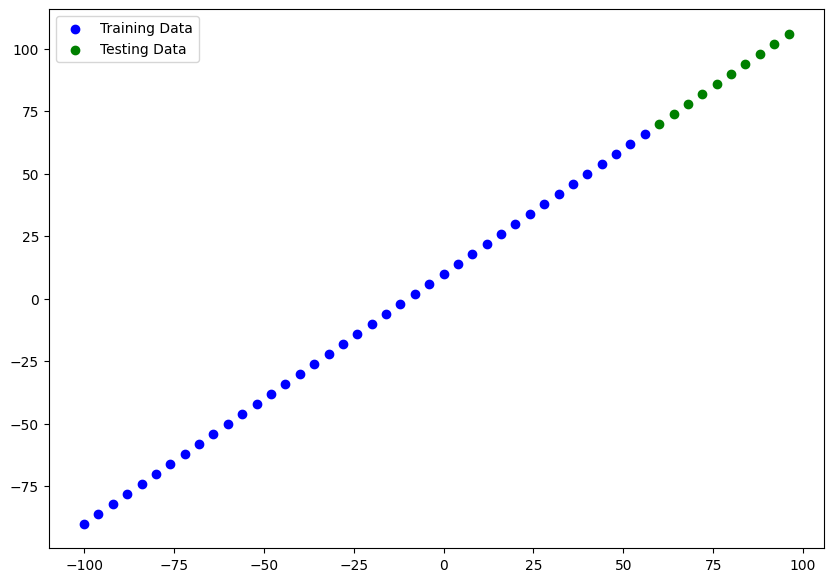

In [24]:
plt.figure(figsize = (10, 7))
plt.scatter(X_train, y_train, c = "b", label = "Training Data")
plt.scatter(X_test, y_test, c = "g", label = "Testing Data")
plt.legend()

In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = [tf.keras.metrics.MAE]
)

In [26]:
model.summary

<bound method Model.summary of <Sequential name=sequential_4, built=False>>

In [27]:
model.build()

In [28]:
#lets build a model with automatically by defining th einput shape argument
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, input_shape = [1]),
    tf.keras.layers.Dense(1, input_shape = [3])
])

model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = [tf.keras.metrics.MAE]
              )
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

* total params = total number of parameters in the model
* trainable parameters - these are the parameter (patterns) a model can update as it trains
* non trainable params = these paramter arent update during traning (this is typical when you bring in already learn patterns or paramters from other model)
**Resource** - mit into to deep learning


In [29]:
model.fit(X_train, y_train, epochs = 100, verbose = 0)

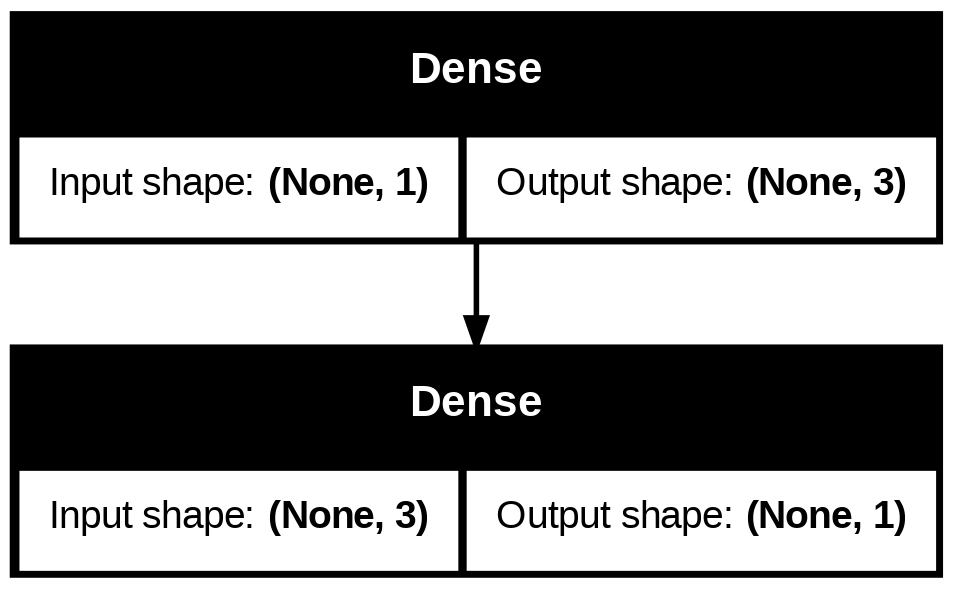

In [30]:
from tensorflow.keras.utils import plot_model
plot_model(model = model, show_shapes = True)

In [31]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape = [1], name = "Input_layer"),
    tf.keras.layers.Dense(1, input_shape = [10], name = "Output_layer")
], name = "model_1")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
              metrics = [tf.keras.metrics.MAE]
              )

In [33]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 351ms/step - loss: 52.9060 - mean_absolute_error: 52.9060
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 47.2795 - mean_absolute_error: 47.2795
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 41.8204 - mean_absolute_error: 41.8204
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 36.5011 - mean_absolute_error: 36.5011
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 31.3539 - mean_absolute_error: 31.3539
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 26.3538 - mean_absolute_error: 26.3538
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 21.5383 - mean_absolute_error: 21.5383
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 16.8864 - mean_absolute_error: 16.8864
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 12.4841 - mean_absolute_error: 12.4841
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 8.9359 - mean_absolute_error: 8.9359
Epoch 11/100
2/2 ━━━━━━━━━━━━━

In [35]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


In [36]:
y_pred

array([[ 68.60784 ],
       [ 72.5274  ],
       [ 76.44695 ],
       [ 80.36651 ],
       [ 84.286064],
       [ 88.20563 ],
       [ 92.125175],
       [ 96.04473 ],
       [ 99.9643  ],
       [103.88384 ]], dtype=float32)

In [37]:
def plot_prediction(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions = y_pred):
  """
  Plots training data, test data and compares predictions tp ground truth labels
  """
  plt.figure(figsize = (10, 7))
  plt.scatter(train_data, train_labels, c="b", label = "Training Data")
  plt.scatter(test_data, test_labels, c="g", label = "Testing Data")
  plt.scatter(test_data, predictions, c = "r", label = "Predictions")
  plt.legend();

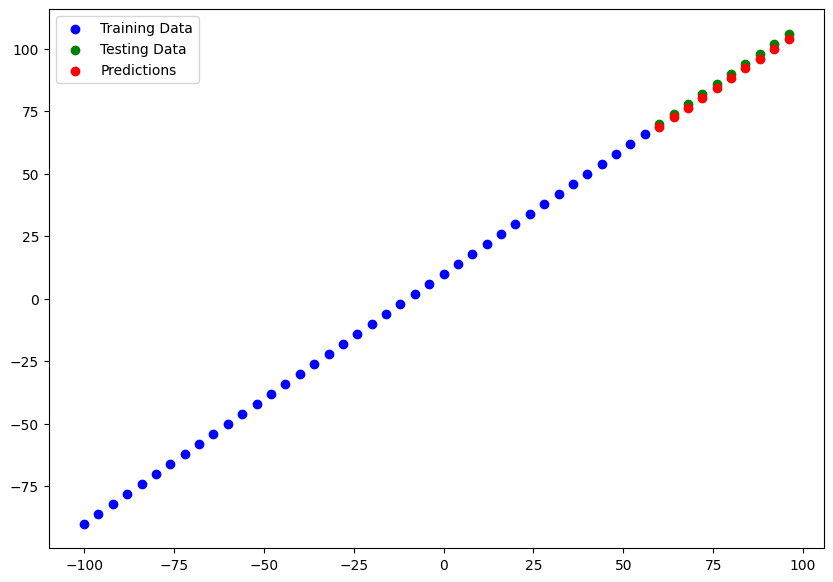

In [38]:
plot_prediction()

## Evaluation metrics

1.   RSME - square the average
2.   MAE - on average how wrong is earch of my model



In [39]:
model.evaluate(y_pred, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 6.3259 - mean_absolute_error: 6.3259


[6.325857639312744, 6.325857639312744]

In [40]:
mae = tf.keras.metrics.MAE(y_test, y_pred)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([1.3921585, 1.4726028, 1.5530472, 1.6334915, 1.7139359, 1.7943726,
       1.8748245, 1.9552689, 2.035698 , 2.1161575], dtype=float32)>

In [41]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 68.60784 ],
       [ 72.5274  ],
       [ 76.44695 ],
       [ 80.36651 ],
       [ 84.286064],
       [ 88.20563 ],
       [ 92.125175],
       [ 96.04473 ],
       [ 99.9643  ],
       [103.88384 ]], dtype=float32)>

In [42]:
tf.constant(y_test)

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [43]:
mae = tf.keras.metrics.MAE(y_test, tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=1.7541557550430298>

In [44]:
# Calculate the mean absolute error
mae = keras.metrics.mean_absolute_error(y_true = y_test,
                                     y_pred = y_pred)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([1.3921585, 1.4726028, 1.5530472, 1.6334915, 1.7139359, 1.7943726,
       1.8748245, 1.9552689, 2.035698 , 2.1161575], dtype=float32)>

In [45]:
# mean square error
mse = keras.metrics.mean_squared_error(y_test, tf.squeeze(y_pred))

mse

<tf.Tensor: shape=(), dtype=float32, numpy=3.1304495334625244>

In [46]:
def mae(y_true, y_pred):
  return keras.metrics.mean_absolute_error(y_true = y_true, y_pred = tf.squeeze(y_pred))

def mse(y_true, y_pred):
  return keras.metrics.mean_squared_error(y_true = y_true, y_pred = tf.squeeze(y_pred))

def rmse(y_true, y_pred):
  return keras.metrics.root_mean_squared_error(y_true = y_true, y_pred = tf.squeeze(y_pred))

### Running experiments to improve our model

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. make your model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.
3. train for longer - give your model more of a chance to find patterns in the data.

Let's do 3 modeliing experiments:

1. `model_1` - same as the original model, 1 layer, tranied for 100 epochs.
2. `model_2` - 2 layers, trained for 100 epochs
3 `model_3` - 2 layers, trained for 500 epochs

In [47]:
X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [48]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

model_1.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = [tf.keras.metrics.MAE]
                )
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs = 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 14.6999 - mean_absolute_error: 14.6999
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.5510 - mean_absolute_error: 9.5510
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.5750 - mean_absolute_error: 8.5750
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.3291 - mean_absolute_error: 9.3291
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.4227 - mean_absolute_error: 8.4227
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.1073 - mean_absolute_error: 9.1073
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.9151 - mean_absolute_error: 7.9151
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 10.8978 - mean_absolute_error: 10.8978
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.6586 - mean_absolute_error: 7.6586
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.9520 - mean_absolute_error: 11.9520
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


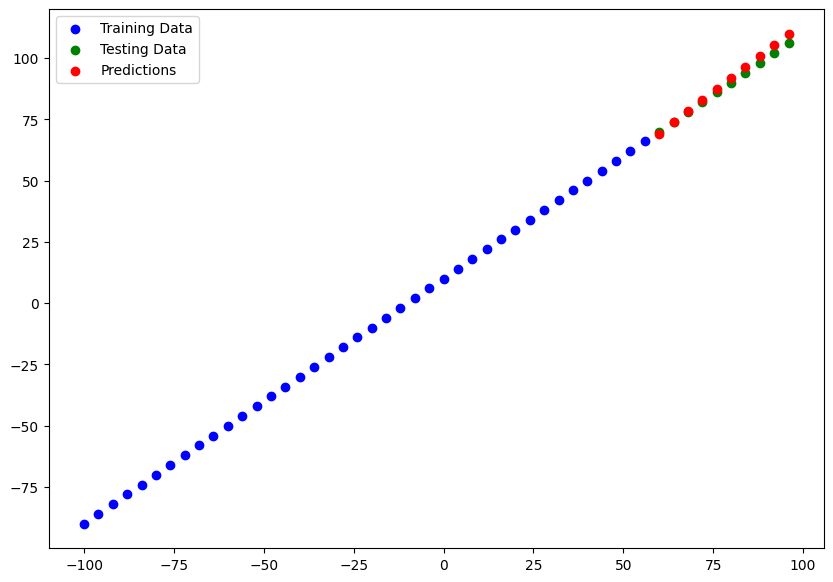

In [49]:
y_pred_1 = model_1.predict(tf.expand_dims(X_test, axis = -1))
plot_prediction(predictions = y_pred_1)

In [50]:
# Calculate MAE for model_1
mae_1 = mae(y_test, y_pred_1)

# Calculate MSE for model_1
mse_1 = mse(y_test, y_pred_1)

print(f"MAE for model_1: {mae_1.numpy()}")
print(f"MSE for model_1: {mse_1.numpy()}")

MAE for model_1: 1.7674118280410767
MSE for model_1: 4.661421775817871


In [51]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape = [1]),
    tf.keras.layers.Dense(1)
])
model_2.compile(loss = tf.keras.losses.mae,
               optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
               metrics = [tf.keras.metrics.MAE]
               )
model_2.fit(tf.expand_dims(X_train, axis = -1), y_train, epochs = 100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - loss: 29.1335 - mean_absolute_error: 29.1335
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 24.3191 - mean_absolute_error: 24.3191
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 19.5961 - mean_absolute_error: 19.5961
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.9163 - mean_absolute_error: 14.9163
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.5177 - mean_absolute_error: 10.5177
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.8336 - mean_absolute_error: 7.8336
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.3802 - mean_absolute_error: 9.3802
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 10.4800 - mean_absolute_error: 10.4800
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.7878 - mean_absolute_error: 10.7878
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.4816 - mean_absolute_error: 10.4816
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


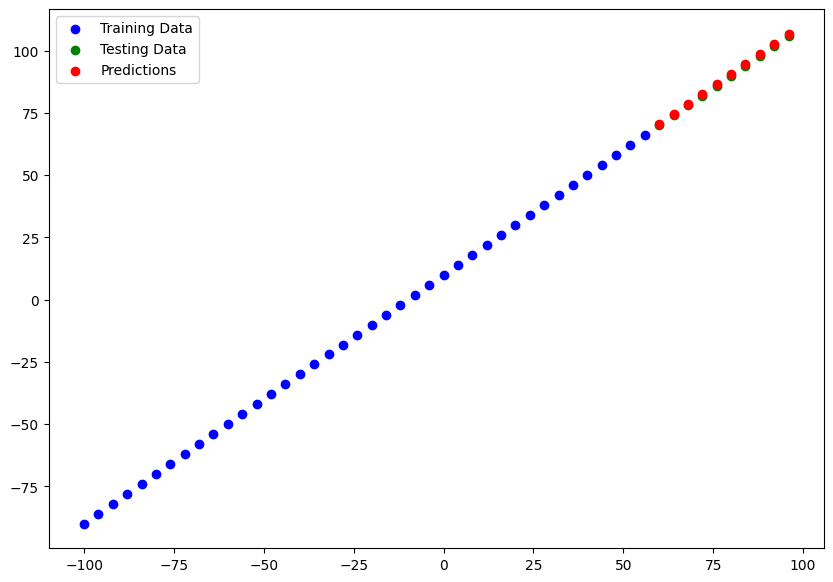

In [52]:
y_pred_2 = model_2.predict(tf.expand_dims(X_test, axis = -1))
plot_prediction(predictions = y_pred_2)

In [53]:
mae_2 = mae(y_test, y_pred_2)
mse_2 = mse(y_test, y_pred_2)
mae_1, mse_1, mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=1.7674118280410767>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.661421775817871>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.6444145441055298>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.42539986968040466>)

In [54]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape = [1]),
    tf.keras.layers.Dense(1)
])
model_3.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = [tf.keras.metrics.MAE]
              )
model_3.fit(tf.expand_dims(X_train, axis = -1), y_train, epochs = 500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 43.1853 - mean_absolute_error: 43.1853
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 23.6143 - mean_absolute_error: 23.6143
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 22.1684 - mean_absolute_error: 22.1684
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 19.2300 - mean_absolute_error: 19.2300
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 17.7971 - mean_absolute_error: 17.7971
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.6942 - mean_absolute_error: 12.6942
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.1119 - mean_absolute_error: 15.1119
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.5952 - mean_absolute_error: 15.5952
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.1737 - mean_absolute_error: 12.1737
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14.7058 - mean_absolute_error: 14.7058
Epoch 11/500
2/2 ━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


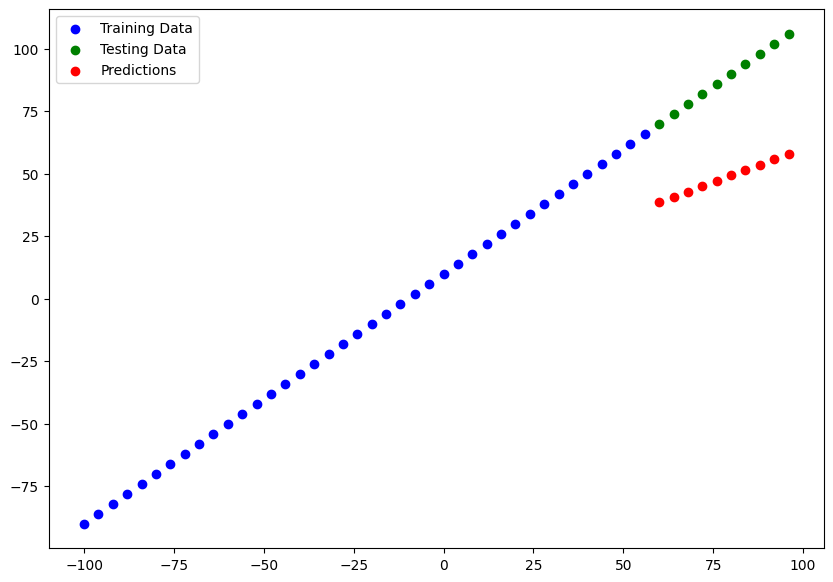

In [55]:
y_pred_3 = model_3.predict(tf.expand_dims(X_test, axis = -1))
plot_prediction(predictions = y_pred_3)


In [56]:
mae_3 = mae(y_test, y_pred_3)
mse_3 = mse(y_test, y_pred_3)
mae_1, mse_1, mae_2, mse_2, mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=1.7674118280410767>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4.661421775817871>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.6444145441055298>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.42539986968040466>,
 <tf.Tensor: shape=(), dtype=float32, numpy=39.7274055480957>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1606.23193359375>)

In [57]:
import numpy as np
import pandas as pd

def to_scalar(x):
    if hasattr(x, 'numpy'):
        return x.numpy().item()
    elif hasattr(x, 'item'):
        return x.item()
    return x

def model_results(name=None, mae=None, mse=None):
    return pd.DataFrame({
        "model": name or [],
        "mae":   [to_scalar(v) for v in (mae or [])],
        "mse":   [to_scalar(v) for v in (mse or [])]
    })

In [58]:
model_results(
    ["model_1", "model_2", "model_3"],
    [mae_1, mae_2, mae_3],
    [mse_1, mse_2, mse_3]
    )

,model,mae,mse
0,model_1,1.767412,4.661422
1,model_2,0.644415,0.425400
2,model_3,39.727406,1606.231934


In [59]:
model_2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

## Saving our model

saving our model allows us to use them outside of google collab or somewhere else.

There are two main formats we can save our model's too:
1. The SavedModel format
2. The HDF5 form

In [60]:
model_2.save("best_model_SavedModel_format.keras")

In [61]:
new_model = tf.keras.models.load_model("best_model_SavedModel_format.keras")
new_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [62]:
new_model.predict(tf.expand_dims(X_test, axis = -1)) == model_2.predict(tf.expand_dims(X_test, axis = -1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

## Larger example


In [130]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import pandas_profiling
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [66]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
df.shape

(1338, 7)

In [67]:
insurance = df.copy()

In [73]:
pandas_profiling.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 61.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [74]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [96]:
df = insurance.copy()

In [97]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], dtype=int, drop_first = True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [132]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis = 1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [137]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)

])

model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
              metrics = [tf.keras.metrics.MAE])
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 11247.7803 - mean_absolute_error: 11247.7803
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7459.3999 - mean_absolute_error: 7459.3999
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7232.3970 - mean_absolute_error: 7232.3970
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7030.3208 - mean_absolute_error: 7030.3208
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6785.7632 - mean_absolute_error: 6785.7632
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6594.9321 - mean_absolute_error: 6594.9321
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6520.9292 - mean_absolute_error: 6520.9292
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6455.7070 - mean_absolute_error: 6455.7070
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6373.5415 - mean_absolute_error: 6373.5415
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6284.4512 - mean_ab

In [138]:
y_pred = model.predict(X_test)

# Ensure y_pred is a numpy array and squeeze to match y_test shape
y_pred_np = y_pred.squeeze() # y_pred is (268,1), y_test is (268,)

# Ensure y_test is also a numpy array for consistent dtypes and operations with sklearn metrics
y_test_np = y_test.to_numpy()

print(f"MAE: {mean_absolute_error(y_test_np, y_pred_np)}")
print(f"MSE: {mean_squared_error(y_test_np, y_pred_np)}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
MAE: 3173.0054491831347
MSE: 43027463.05044663


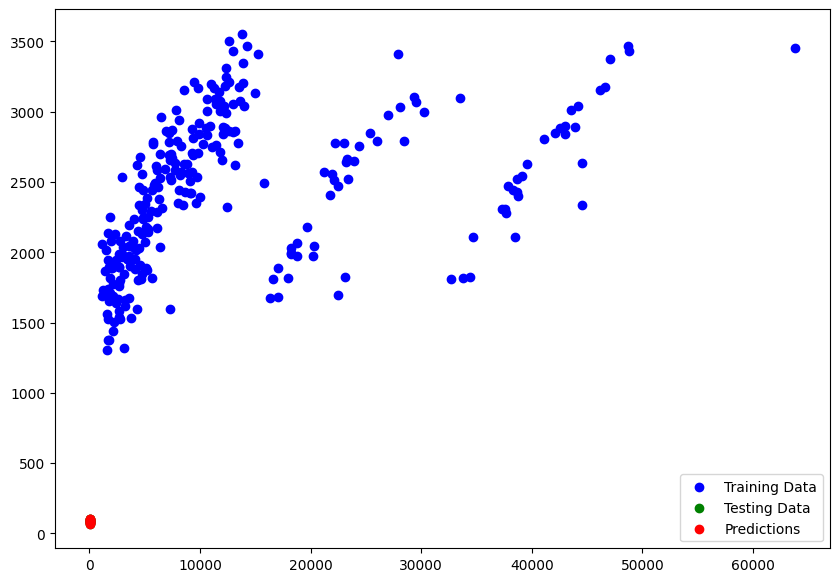

In [136]:
plot_prediction(y_test_np, y_pred_np)

In [139]:
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import StandardScaler

X_train_scaled = minmax_scale(X_train)
X_test_scaled = minmax_scale(X_test)

X_scaled = StandardScaler()
X_train_scaled = X_scaled.fit_transform(X_train)
X_test_scaled = X_scaled.fit_transform(X_test)


In [141]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)

])
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.1),
              metrics = [tf.keras.metrics.MAE])
model.fit(X_train_scaled, y_train, epochs = 100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 3491.0259 - mean_absolute_error: 3491.0259
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3496.2090 - mean_absolute_error: 3496.2090
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3495.1655 - mean_absolute_error: 3495.1655
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3494.7913 - mean_absolute_error: 3494.7913
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3492.9375 - mean_absolute_error: 3492.9375
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3492.3689 - mean_absolute_error: 3492.3689
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3495.0286 - mean_absolute_error: 3495.0286
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3493.6531 - mean_absolute_error: 3493.6531
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3496.0459 - mean_absolute_error: 3496.0459
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3493.2361 - mean_abso